# 06 SVM Loan Approval Classification

## Project Overview

This project develops a complete machine learning workflow for predicting whether a loan application will be approved or rejected. The main algorithm is Support Vector Machine (SVM), which finds the optimal hyperplane that separates different classes in the feature space.

The notebook includes:

- Business and problem understanding.
- Robust data ingestion and validation.
- Data cleaning and exploratory analysis.
- Feature preprocessing using reusable pipelines.
- Baseline SVM development.
- Hyperparameter optimization.
- Comparison with multiple classification algorithms.
- Threshold analysis.
- Feature importance interpretation via Permutation Importance.
- A final reusable SVM training function with editable parameters.
- Serialization of the complete production pipeline.

## Project Metadata

- Project name: `06_SVM_Loan_Approval`
- Dataset: `loan_approval_dataset.csv`
- Target variable: `loan_status`
- Positive class: `Approved`
- Primary algorithm: SVM Classifier
- Primary evaluation metric: ROC-AUC
- Deployment-ready artifact: complete preprocessing and model pipeline


In [1]:
from pathlib import Path
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Environment setup completed successfully.")


Environment setup completed successfully.


## Phase 1: Business Understanding and Problem Definition

Loan approval is a binary classification problem.

A useful model can support:
- Faster preliminary screening.
- Consistent treatment of applications.

SVM is selected as the primary model because it:
- Is highly effective in high-dimensional spaces.
- Uses the kernel trick to handle non-linear relationships.
- Focuses on the margin of separation, potentially leading to robust generalization.


In [2]:
business_definition = {
    "problem_type": "Binary classification",
    "target": "loan_status",
    "positive_class": "Approved",
    "primary_model": "SVM Classifier",
    "primary_metric": "ROC-AUC",
    "supporting_metrics": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
    ],
}

business_definition


{'problem_type': 'Binary classification',
 'target': 'loan_status',
 'positive_class': 'Approved',
 'primary_model': 'SVM Classifier',
 'primary_metric': 'ROC-AUC',
 'supporting_metrics': ['Accuracy', 'Precision', 'Recall', 'F1-score']}

## Phase 2: Data Ingestion


In [3]:
candidate_data_paths = [
    Path("../data/raw/loan_approval_dataset.csv"),
    Path("data/raw/loan_approval_dataset.csv"),
    Path("loan_approval_dataset.csv"),
]

data_path = next(
    (path for path in candidate_data_paths if path.exists()),
    None,
)

if data_path is None:
    raise FileNotFoundError("The loan approval dataset was not found.")

df = pd.read_csv(data_path)

print(f"Dataset path: {data_path.resolve()}")
print(f"Dataset dimensions: {df.shape[0]:,} rows and {df.shape[1]:,} columns")

display(df.head())
df.info()


Dataset path: C:\Users\soham\Desktop\ahmed\NTI-ML\06_SVM_Loan_Approval\data\raw\loan_approval_dataset.csv
Dataset dimensions: 4,269 rows and 13 columns


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


## Phase 3: Data Cleaning and Quality Assessment


In [4]:
clean_df = df.copy()

clean_df.columns = clean_df.columns.str.strip()

object_columns = clean_df.select_dtypes(include="object").columns
for column in object_columns:
    clean_df[column] = clean_df[column].str.strip()

missing_summary = (
    clean_df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_percentage=lambda table: table["missing_count"] / len(clean_df) * 100
    )
)

display(missing_summary)

target_column = "loan_status"
clean_df = clean_df.drop(columns=["loan_id"]).copy()

print(f"Cleaned dataset dimensions: {clean_df.shape}")


,missing_count,missing_percentage
loan_id,0,0.0000
no_of_dependents,0,0.0000
education,0,0.0000
self_employed,0,0.0000
income_annum,0,0.0000
loan_amount,0,0.0000
loan_term,0,0.0000
cibil_score,0,0.0000
residential_assets_value,0,0.0000
commercial_assets_value,0,0.0000


Cleaned dataset dimensions: (4269, 12)


## Phase 4: Exploratory Data Analysis


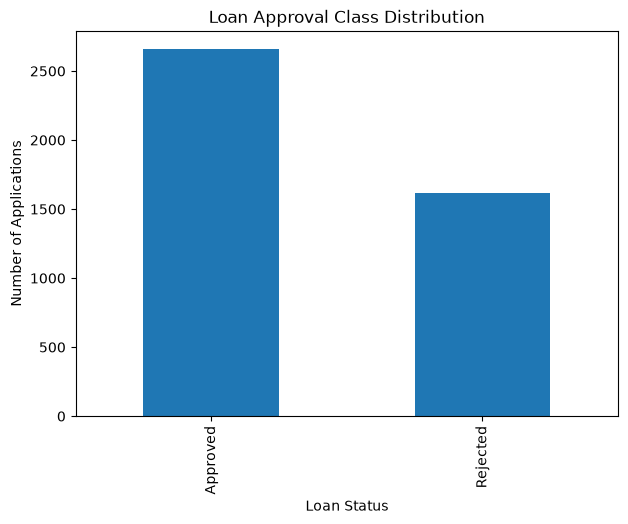

In [5]:
target_counts = clean_df[target_column].value_counts()
target_percentages = (
    clean_df[target_column]
    .value_counts(normalize=True)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(7, 5))
target_counts.plot(kind="bar", ax=ax)
ax.set_title("Loan Approval Class Distribution")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Number of Applications")
plt.show()


In [6]:
eda_df = clean_df.copy()
eda_df["loan_status_binary"] = eda_df[target_column].map({"Rejected": 0, "Approved": 1})

categorical_columns = clean_df.select_dtypes(include=["object"]).drop(columns=[target_column]).columns.tolist()

for col in categorical_columns:
    display(eda_df.groupby(col)["loan_status_binary"].mean().to_frame("approval_rate"))


,approval_rate
education,
Graduate,0.6245
Not Graduate,0.6198


,approval_rate
self_employed,
No,0.6220
Yes,0.6223


## Phase 5: Feature and Target Preparation
SVMs are highly sensitive to feature scaling, so we ensure all numerical variables are standardized using StandardScaler.


In [7]:
X = clean_df.drop(columns=[target_column]).copy()
y = clean_df[target_column].map({"Rejected": 0, "Approved": 1}).astype(int)

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)


## Phase 6: Stratified Train-Test Split


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


Training set: (3415, 11)
Testing set: (854, 11)


## Phase 7: Baseline SVM Model


In [9]:
baseline_svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", SVC(probability=True, random_state=RANDOM_STATE))
    ]
)

baseline_svm_pipeline.fit(X_train, y_train)
baseline_preds = baseline_svm_pipeline.predict(X_test)
print(f"Baseline SVM Accuracy: {accuracy_score(y_test, baseline_preds):.4f}")
print(f"Baseline SVM ROC AUC: {roc_auc_score(y_test, baseline_svm_pipeline.predict_proba(X_test)[:, 1]):.4f}")


Baseline SVM Accuracy: 0.9461
Baseline SVM ROC AUC: 0.9876


## Phase 8: SVM Hyperparameter Tuning
We use GridSearchCV to find optimal hyperparameters (C, gamma, kernel).


In [10]:
svm_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", SVC(probability=True, random_state=RANDOM_STATE))
    ]
)

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto", 0.1],
    "model__kernel": ["rbf", "linear"]
}

svm_grid_search = GridSearchCV(
    estimator=svm_tuning_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

best_svm_pipeline = svm_grid_search.best_estimator_
print(f"Best parameters: {svm_grid_search.best_params_}")
print(f"Best CV ROC-AUC: {svm_grid_search.best_score_:.4f}")


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV ROC-AUC: 0.9873


## Phase 9: Tuned SVM Evaluation


              precision    recall  f1-score   support

           0       0.94      0.93      0.93       323
           1       0.96      0.96      0.96       531

    accuracy                           0.95       854
   macro avg       0.95      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854



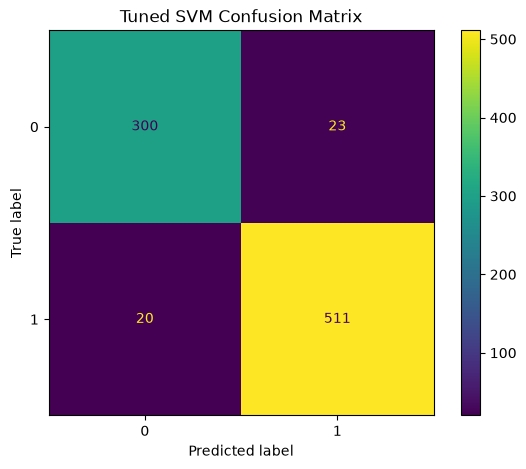

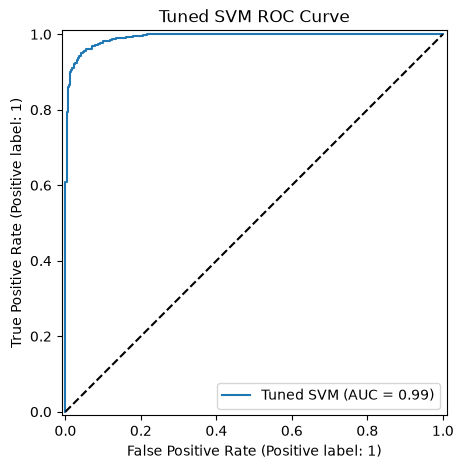

In [11]:
optimized_predictions = best_svm_pipeline.predict(X_test)
optimized_probabilities = best_svm_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, optimized_predictions))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, optimized_predictions, ax=ax)
ax.set_title("Tuned SVM Confusion Matrix")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, optimized_probabilities, name="Tuned SVM", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="black")
ax.set_title("Tuned SVM ROC Curve")
plt.show()


## Phase 10: Classification Model Comparison


,model,accuracy,f1_score,roc_auc
2,Random Forest,0.9813,0.9850,0.9988
4,Tuned SVM,0.9496,0.9596,0.9919
1,Decision Tree,0.9684,0.9744,0.9884
3,Baseline SVM,0.9461,0.9566,0.9876
0,Logistic Regression,0.9145,0.9321,0.9726


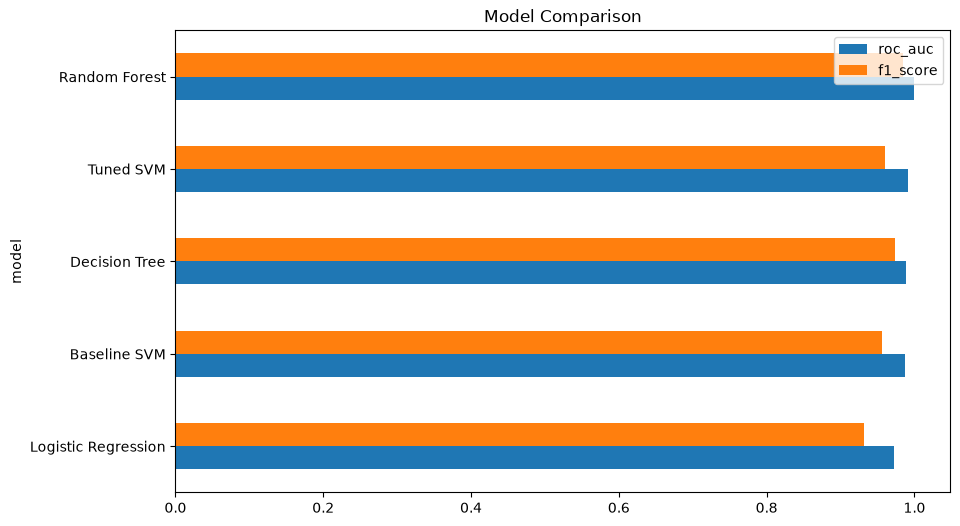

In [12]:
comparison_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Baseline SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Tuned SVM": best_svm_pipeline.named_steps["model"]
}

comparison_results = []
for name, model in comparison_models.items():
    pipe = Pipeline([("preprocessor", clone(preprocessor)), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    comparison_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "f1_score": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)
    })

model_comparison_df = pd.DataFrame(comparison_results).sort_values("roc_auc", ascending=False)
display(model_comparison_df)

fig, ax = plt.subplots(figsize=(10, 6))
model_comparison_df.sort_values("roc_auc").plot(kind="barh", x="model", y=["roc_auc", "f1_score"], ax=ax)
ax.set_title("Model Comparison")
plt.show()


## Phase 11: Threshold Analysis


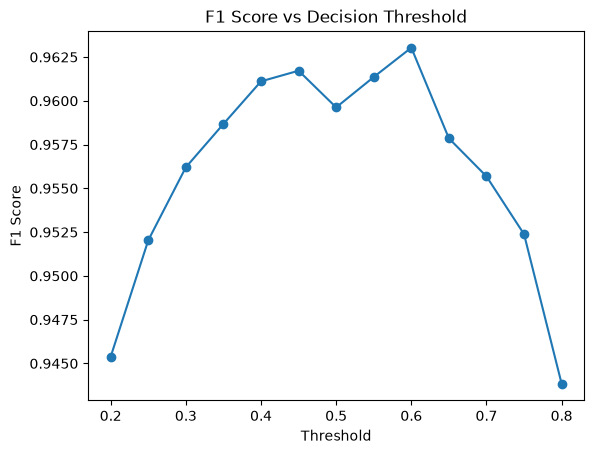

In [13]:
thresholds = np.arange(0.2, 0.85, 0.05)
f1_scores = []
for t in thresholds:
    preds = (optimized_probabilities >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

plt.plot(thresholds, f1_scores, marker="o")
plt.title("F1 Score vs Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()


## Phase 12: Feature Importance via Permutation
Since SVM with non-linear kernels doesn't provide native feature importances, we use Permutation Importance.


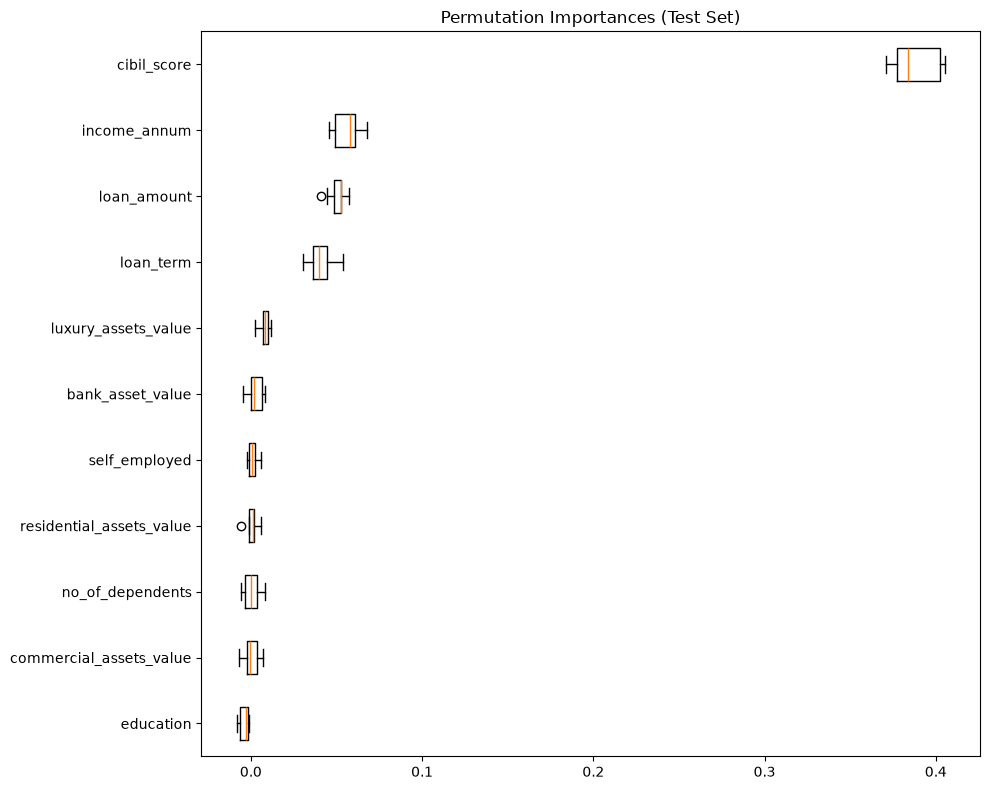

In [14]:
result = permutation_importance(best_svm_pipeline, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X_test.columns[sorted_idx])
ax.set_title("Permutation Importances (Test Set)")
fig.tight_layout()
plt.show()


## Phase 13: Final Reusable Function


In [15]:
def train_svm_loan_model(data, C=1.0, kernel='rbf', gamma='scale'):
    # A reusable wrapper for training
    X = data.drop(columns=["loan_status", "loan_id"], errors='ignore')
    y = data["loan_status"].map({"Rejected": 0, "Approved": 1}).astype(int)
    
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    
    prep = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ])
    
    pipe = Pipeline([
        ("preprocessor", prep),
        ("model", SVC(C=C, kernel=kernel, gamma=gamma, probability=True, random_state=42))
    ])
    pipe.fit(X, y)
    return pipe

final_pipeline = train_svm_loan_model(clean_df, 
                                      C=svm_grid_search.best_params_["model__C"], 
                                      kernel=svm_grid_search.best_params_["model__kernel"],
                                      gamma=svm_grid_search.best_params_["model__gamma"])


## Phase 14: Model Serialization


In [16]:
if Path.cwd().name == "notebooks":
    model_directory = Path("../models")
else:
    model_directory = Path("models")

model_directory.mkdir(exist_ok=True)
pipeline_path = model_directory / "svm_loan_approval_pipeline.pkl"
joblib.dump(final_pipeline, pipeline_path)
print(f"Pipeline saved to {pipeline_path}")


Pipeline saved to ..\models\svm_loan_approval_pipeline.pkl


## Phase 15: Artifact Validation


In [17]:
reloaded_pipeline = joblib.load(pipeline_path)
reloaded_predictions = reloaded_pipeline.predict(X_test)
print(f"Validation successful. Reloaded accuracy: {accuracy_score(y_test, reloaded_predictions):.4f}")


Validation successful. Reloaded accuracy: 0.9719
